# Notebook de Inferência e Métricas dos Modelos OTFT

Este notebook foi criado para:

1. Carregar modelos salvos em `models/` (scikit-learn `.pkl` e TensorFlow `.keras`),
2. Regenerar datasets sintéticos por tecnologia (`Org1`, `Org2`, `Org3`) com base nos JSONs em `inputs/tipo p/`,
3. Calcular métricas diretamente na inferência (sem depender dos logs em `artefatos/`),
4. Gerar gráficos em padrão de artigo (ABNT, fonte 12).

## Observação metodológica

As métricas reportadas aqui são todas calculadas na fase de inferência. Isso permite comparar modelos de forma consistente mesmo quando o mapeamento histórico de `artefatos/` não está disponível.

In [2]:
from __future__ import annotations

import json
import pickle
import warnings
from dataclasses import dataclass
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from modules_otft._generate_synthetic_data import SyntheticFromSettings
from modules_otft._inferency import prepare_mlp_features
from modules_otft._model import TFTModel

warnings.filterwarnings("ignore")

BASE_PATH = Path.cwd()
FIGURES_DIR = BASE_PATH / "figures_mlp"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Estilo global (artigo, ABNT, fonte 12)
plt.rcParams.update(
    {
        "font.family": "serif",
        "font.size": 12,
        "axes.titlesize": 12,
        "axes.labelsize": 12,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 12,
        "figure.titlesize": 12,
        "savefig.dpi": 300,
    }
)

EPS = 1e-30


def salvar_figura_abnt(fig: plt.Figure, nome_arquivo: str, titulo: str, fonte: str = "Fonte: Elaborado pelo autor.") -> Path:
    """Salva figura no padrão de artigo com título e fonte."""
    fig.suptitle(titulo, y=0.98)
    fig.text(0.5, 0.01, fonte, ha="center", va="bottom", fontsize=12)
    fig.tight_layout(rect=[0, 0.05, 1, 0.95])

    out_path = FIGURES_DIR / nome_arquivo
    fig.savefig(out_path, bbox_inches="tight")
    print(f"[OK] Figura salva: {out_path}")
    return out_path


@dataclass
class ModelBundle:
    org: str
    model_id: str
    model_path: Path
    scaler_x_path: Path
    scaler_y_path: Path
    inputs_json: Path
    primary: bool = False


In [15]:
# Registro editável de modelos por tecnologia

MODEL_REGISTRY: list[ModelBundle] = [
    # Org1 (modelo principal + extras Keras)
    ModelBundle(
        org="Org1",
        model_id="org1_exp1",
        model_path=BASE_PATH / "models/Mlp_Org1/exp3/mlp_model_v1.pkl",
        scaler_x_path=BASE_PATH / "models/Mlp_Org1/exp3/mlp_model_v1_scaler_X.pkl",
        scaler_y_path=BASE_PATH / "models/Mlp_Org1/exp3/mlp_model_v1_scaler_Y.pkl",
        inputs_json=BASE_PATH / "inputs/tipo p/inputs_Org1_SB.json",
        primary=True,
    ),
    # Org2
    ModelBundle(
        org="Org2",
        model_id="org2_exp1",
        model_path=BASE_PATH / "models/Mlp_Org2/exp1/mlp_model_org2.pkl",
        scaler_x_path=BASE_PATH / "models/Mlp_Org2/exp1/mlp_model_org2_scaler_X.pkl",
        scaler_y_path=BASE_PATH / "models/Mlp_Org2/exp1/mlp_model_org2_scaler_Y.pkl",
        inputs_json=BASE_PATH / "inputs/tipo p/inputs_Org2_SB.json",
        primary=True,
    ),
    # Org3
    ModelBundle(
        org="Org3",
        model_id="org3_exp1",
        model_path=BASE_PATH / "models/Mlp_Org3/exp1/mlp_model_org3.pkl",
        scaler_x_path=BASE_PATH / "models/Mlp_Org3/exp1/mlp_model_org3_scaler_X.pkl",
        scaler_y_path=BASE_PATH / "models/Mlp_Org3/exp1/mlp_model_org3_scaler_Y.pkl",
        inputs_json=BASE_PATH / "inputs/tipo p/inputs_Org3_SB.json",
        primary=True,
    ),
        # Org4
    ModelBundle(
        org="Org4",
        model_id="org4_exp1",
        model_path=BASE_PATH / "models/Mlp_Org4/exp1/mlp_model_org4.pkl",
        scaler_x_path=BASE_PATH / "models/Mlp_Org4/exp1/mlp_model_org4_scaler_X.pkl",
        scaler_y_path=BASE_PATH / "models/Mlp_Org4/exp1/mlp_model_org4_scaler_Y.pkl",
        inputs_json=BASE_PATH / "inputs/tipo p/inputs_Org4_SB.json",
        primary=True,
    )
]

REGISTRY_DF = pd.DataFrame(
    [
        {
            "org": m.org,
            "model_id": m.model_id,
            "model_path": str(m.model_path),
            "inputs_json": str(m.inputs_json),
            "primary": m.primary,
        }
        for m in MODEL_REGISTRY
    ]
)
REGISTRY_DF

,org,model_id,model_path,inputs_json,primary
0,Org1,org1_exp1,/home/rsb6/Desktop/TCC/TCC implementation/Mode...,/home/rsb6/Desktop/TCC/TCC implementation/Mode...,True
1,Org2,org2_exp1,/home/rsb6/Desktop/TCC/TCC implementation/Mode...,/home/rsb6/Desktop/TCC/TCC implementation/Mode...,True
2,Org3,org3_exp1,/home/rsb6/Desktop/TCC/TCC implementation/Mode...,/home/rsb6/Desktop/TCC/TCC implementation/Mode...,True
3,Org4,org4_exp1,/home/rsb6/Desktop/TCC/TCC implementation/Mode...,/home/rsb6/Desktop/TCC/TCC implementation/Mode...,True


In [16]:
def load_settings_from_json_blocks(json_path: Path) -> dict[str, Any]:
    """Lê JSON de inputs (lista de blocos) e converte para dicionário único."""
    with json_path.open("r", encoding="utf-8") as f:
        blocks = json.load(f)

    if not isinstance(blocks, list):
        raise ValueError(f"Formato inesperado em {json_path}: esperado lista de blocos.")

    settings: dict[str, Any] = {"_json_path": str(json_path), "_json_blocks": blocks}
    for block in blocks:
        if isinstance(block, dict):
            settings.update(block)

    return settings


def regenerate_synthetic_dataset(org: str, inputs_json: Path, out_root: Path, *, resample_n_points: int = 1500, reset_index: bool = True) -> list[Path]:
    """Regenera o dataset sintético para uma tecnologia e retorna lista de .npz."""
    settings = load_settings_from_json_blocks(inputs_json)
    org_root = out_root / org
    org_root.mkdir(parents=True, exist_ok=True)

    index_file = org_root / "index_generated.json"
    if reset_index and index_file.exists():
        index_file.unlink()

    gen = SyntheticFromSettings(settings=settings, model_cls=TFTModel, out_root=str(org_root))
    generated_npz_paths = gen.generate(
        n_variations_per_file=0,
        resample_n_points=resample_n_points,
        variation_mode="voltages",
        voltage_increment=2.0,
        voltage_max_variation=10,
        save_csv=True,
        save_npz=True,
        verbose=False,
    )

    existing_paths = [Path(p) for p in generated_npz_paths if Path(p).exists()]
    print(f"[OK] {org}: {len(existing_paths)} arquivos .npz válidos gerados em {org_root}")
    return existing_paths


In [17]:
def load_any_model(model_path: Path):
    """Carrega modelo sklearn (.pkl) ou tensorflow (.keras)."""
    suffix = model_path.suffix.lower()

    if suffix == ".pkl":
        with model_path.open("rb") as f:
            model_obj = pickle.load(f)

        if isinstance(model_obj, dict) and "model" in model_obj:
            model = model_obj["model"]
        else:
            model = model_obj
        backend = "sklearn"

    elif suffix == ".keras":
        try:
            from tensorflow.keras.models import load_model  # type: ignore
        except Exception as exc:
            raise RuntimeError(
                "TensorFlow não está disponível no ambiente. "
                "Instale tensorflow para carregar modelos .keras."
            ) from exc

        model = load_model(model_path, compile=False)
        backend = "keras"

    else:
        raise ValueError(f"Extensão não suportada: {model_path}")

    return model, backend


def load_scalers(bundle: ModelBundle):
    with bundle.scaler_x_path.open("rb") as f:
        scaler_x = pickle.load(f)
    with bundle.scaler_y_path.open("rb") as f:
        scaler_y = pickle.load(f)
    return scaler_x, scaler_y


def model_predict_scaled(model, backend: str, x_scaled: np.ndarray) -> np.ndarray:
    """Retorna predição na escala do treinamento (antes do inverse do scaler_y)."""
    if backend == "keras":
        y_pred = model.predict(x_scaled, verbose=0)
    else:
        y_pred = model.predict(x_scaled)
    return np.asarray(y_pred).reshape(-1, 1)


def safe_log_abs(i_values: np.ndarray, eps: float = EPS) -> np.ndarray:
    return np.log(np.clip(np.abs(i_values), eps, None))


def calc_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict[str, float]:
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = float(np.sqrt(mse))
    r2 = r2_score(y_true, y_pred)
    return {
        "mse": float(mse),
        "mae": float(mae),
        "rmse": rmse,
        "r2": float(r2),
    }


In [18]:
SYNTH_OUT_ROOT = BASE_PATH / "synthetic_inference_runs"
SYNTH_OUT_ROOT.mkdir(parents=True, exist_ok=True)

# 1) Regenera datasets por tecnologia (uma vez por Org)
org_to_inputs = {}
for bundle in MODEL_REGISTRY:
    if bundle.org not in org_to_inputs:
        org_to_inputs[bundle.org] = bundle.inputs_json

org_npz_index: dict[str, list[Path]] = {}
for org, json_path in org_to_inputs.items():
    org_npz_index[org] = regenerate_synthetic_dataset(
        org=org,
        inputs_json=json_path,
        out_root=SYNTH_OUT_ROOT,
        resample_n_points=1500,
        reset_index=True,
    )

# 2) Inferência e métricas
curve_rows: list[dict[str, Any]] = []
point_rows: list[dict[str, Any]] = []

for bundle in MODEL_REGISTRY:
    if not bundle.model_path.exists():
        print(f"[WARN] Modelo não encontrado: {bundle.model_path}")
        continue

    try:
        model, backend = load_any_model(bundle.model_path)
    except Exception as exc:
        print(f"[WARN] Falha ao carregar modelo {bundle.model_id}: {exc}")
        continue

    try:
        scaler_x, scaler_y = load_scalers(bundle)
    except Exception as exc:
        print(f"[WARN] Falha ao carregar scalers {bundle.model_id}: {exc}")
        continue

    npz_paths = org_npz_index.get(bundle.org, [])
    if not npz_paths:
        print(f"[WARN] Sem .npz para {bundle.org}")
        continue

    print(f"[RUN] {bundle.model_id}: avaliando {len(npz_paths)} curvas")

    for npz_path in npz_paths:
        data = np.load(npz_path, allow_pickle=True)
        v_values = np.asarray(data["V"], dtype=float).ravel()
        i_true = np.asarray(data["I"], dtype=float).ravel()
        meta = data["meta"].tolist() if "meta" in data.files else {}

        is_transfer = bool(meta.get("is_transfer", "transfer" in npz_path.name.lower()))
        curve_type = "transfer" if is_transfer else "output"
        fixed_voltage = float(meta.get("fixed_voltage_simulated", np.nan))

        x_raw = prepare_mlp_features(v_values, fixed_voltage, is_transfer)
        x_scaled = scaler_x.transform(x_raw)

        y_pred_scaled = model_predict_scaled(model, backend, x_scaled)
        y_pred_ln = scaler_y.inverse_transform(y_pred_scaled).ravel()

        y_true_ln = safe_log_abs(i_true)
        i_pred_abs = np.exp(y_pred_ln)
        i_true_abs = np.abs(i_true)

        metrics_ln = calc_metrics(y_true_ln, y_pred_ln)
        metrics_abs = calc_metrics(i_true_abs, i_pred_abs)

        curve_rows.append(
            {
                "org": bundle.org,
                "model_id": bundle.model_id,
                "primary": bundle.primary,
                "backend": backend,
                "curve_type": curve_type,
                "fixed_voltage": fixed_voltage,
                "npz_path": str(npz_path),
                "n_points": int(len(v_values)),
                "mse_ln": metrics_ln["mse"],
                "mae_ln": metrics_ln["mae"],
                "rmse_ln": metrics_ln["rmse"],
                "r2_ln": metrics_ln["r2"],
                "mse_abs": metrics_abs["mse"],
                "mae_abs": metrics_abs["mae"],
                "rmse_abs": metrics_abs["rmse"],
                "r2_abs": metrics_abs["r2"],
            }
        )

        point_rows.append(
            {
                "org": bundle.org,
                "model_id": bundle.model_id,
                "primary": bundle.primary,
                "curve_type": curve_type,
                "fixed_voltage": fixed_voltage,
                "V": v_values,
                "I_true_abs": i_true_abs,
                "I_pred_abs": i_pred_abs,
                "y_true_ln": y_true_ln,
                "y_pred_ln": y_pred_ln,
                "residual_ln": y_true_ln - y_pred_ln,
            }
        )

curves_df = pd.DataFrame(curve_rows)

if curves_df.empty:
    raise RuntimeError("Nenhuma métrica foi gerada. Verifique modelos, scalers e dados sintéticos.")

metrics_by_model_df = (
    curves_df.groupby(["org", "model_id", "primary", "backend"], as_index=False)
    .agg(
        n_curves=("npz_path", "count"),
        n_points=("n_points", "sum"),
        mse_ln=("mse_ln", "mean"),
        mae_ln=("mae_ln", "mean"),
        rmse_ln=("rmse_ln", "mean"),
        r2_ln=("r2_ln", "mean"),
        mse_abs=("mse_abs", "mean"),
        mae_abs=("mae_abs", "mean"),
        rmse_abs=("rmse_abs", "mean"),
        r2_abs=("r2_abs", "mean"),
    )
    .sort_values(["org", "primary", "r2_ln"], ascending=[True, False, False])
)

metrics_primary_df = metrics_by_model_df[metrics_by_model_df["primary"]].copy().sort_values("org")

metrics_csv = FIGURES_DIR / "metrics_inferencia.csv"
metrics_by_model_df.to_csv(metrics_csv, index=False)

metrics_curve_csv = FIGURES_DIR / "metrics_inferencia_por_curva.csv"
curves_df.to_csv(metrics_curve_csv, index=False)

print(f"[OK] CSV salvo: {metrics_csv}")
print(f"[OK] CSV salvo: {metrics_curve_csv}")

display(metrics_by_model_df)



Index salvo em: /home/rsb6/Desktop/TCC/TCC implementation/Model_OTFT/synthetic_inference_runs/Org1/index_generated.json
[OK] Org1: 25 arquivos .npz válidos gerados em /home/rsb6/Desktop/TCC/TCC implementation/Model_OTFT/synthetic_inference_runs/Org1

Index salvo em: /home/rsb6/Desktop/TCC/TCC implementation/Model_OTFT/synthetic_inference_runs/Org2/index_generated.json
[OK] Org2: 25 arquivos .npz válidos gerados em /home/rsb6/Desktop/TCC/TCC implementation/Model_OTFT/synthetic_inference_runs/Org2

Index salvo em: /home/rsb6/Desktop/TCC/TCC implementation/Model_OTFT/synthetic_inference_runs/Org3/index_generated.json
[OK] Org3: 20 arquivos .npz válidos gerados em /home/rsb6/Desktop/TCC/TCC implementation/Model_OTFT/synthetic_inference_runs/Org3

Index salvo em: /home/rsb6/Desktop/TCC/TCC implementation/Model_OTFT/synthetic_inference_runs/Org4/index_generated.json
[OK] Org4: 25 arquivos .npz válidos gerados em /home/rsb6/Desktop/TCC/TCC implementation/Model_OTFT/synthetic_inference_runs/O

,org,model_id,primary,backend,n_curves,n_points,mse_ln,mae_ln,rmse_ln,r2_ln,mse_abs,mae_abs,rmse_abs,r2_abs
0,Org1,org1_exp1,True,sklearn,25,37500,0.025792,0.111261,0.136897,0.961400,1.214133,0.511465,0.560964,0.925665
1,Org2,org2_exp1,True,sklearn,25,37500,0.113143,0.144089,0.296913,0.698402,6.007990,1.473712,1.947011,0.857877
2,Org3,org3_exp1,True,sklearn,20,30000,0.194010,0.219944,0.412558,0.597346,4785.527810,51.385173,60.857129,0.753097
3,Org4,org4_exp1,True,sklearn,25,37500,2.578782,0.301543,1.034117,0.428479,1168.442328,14.663028,24.005484,0.789890


[OK] Figura salva: /home/rsb6/Desktop/TCC/TCC implementation/Model_OTFT/figures_mlp/fig1_curvas_iv_representativas.png


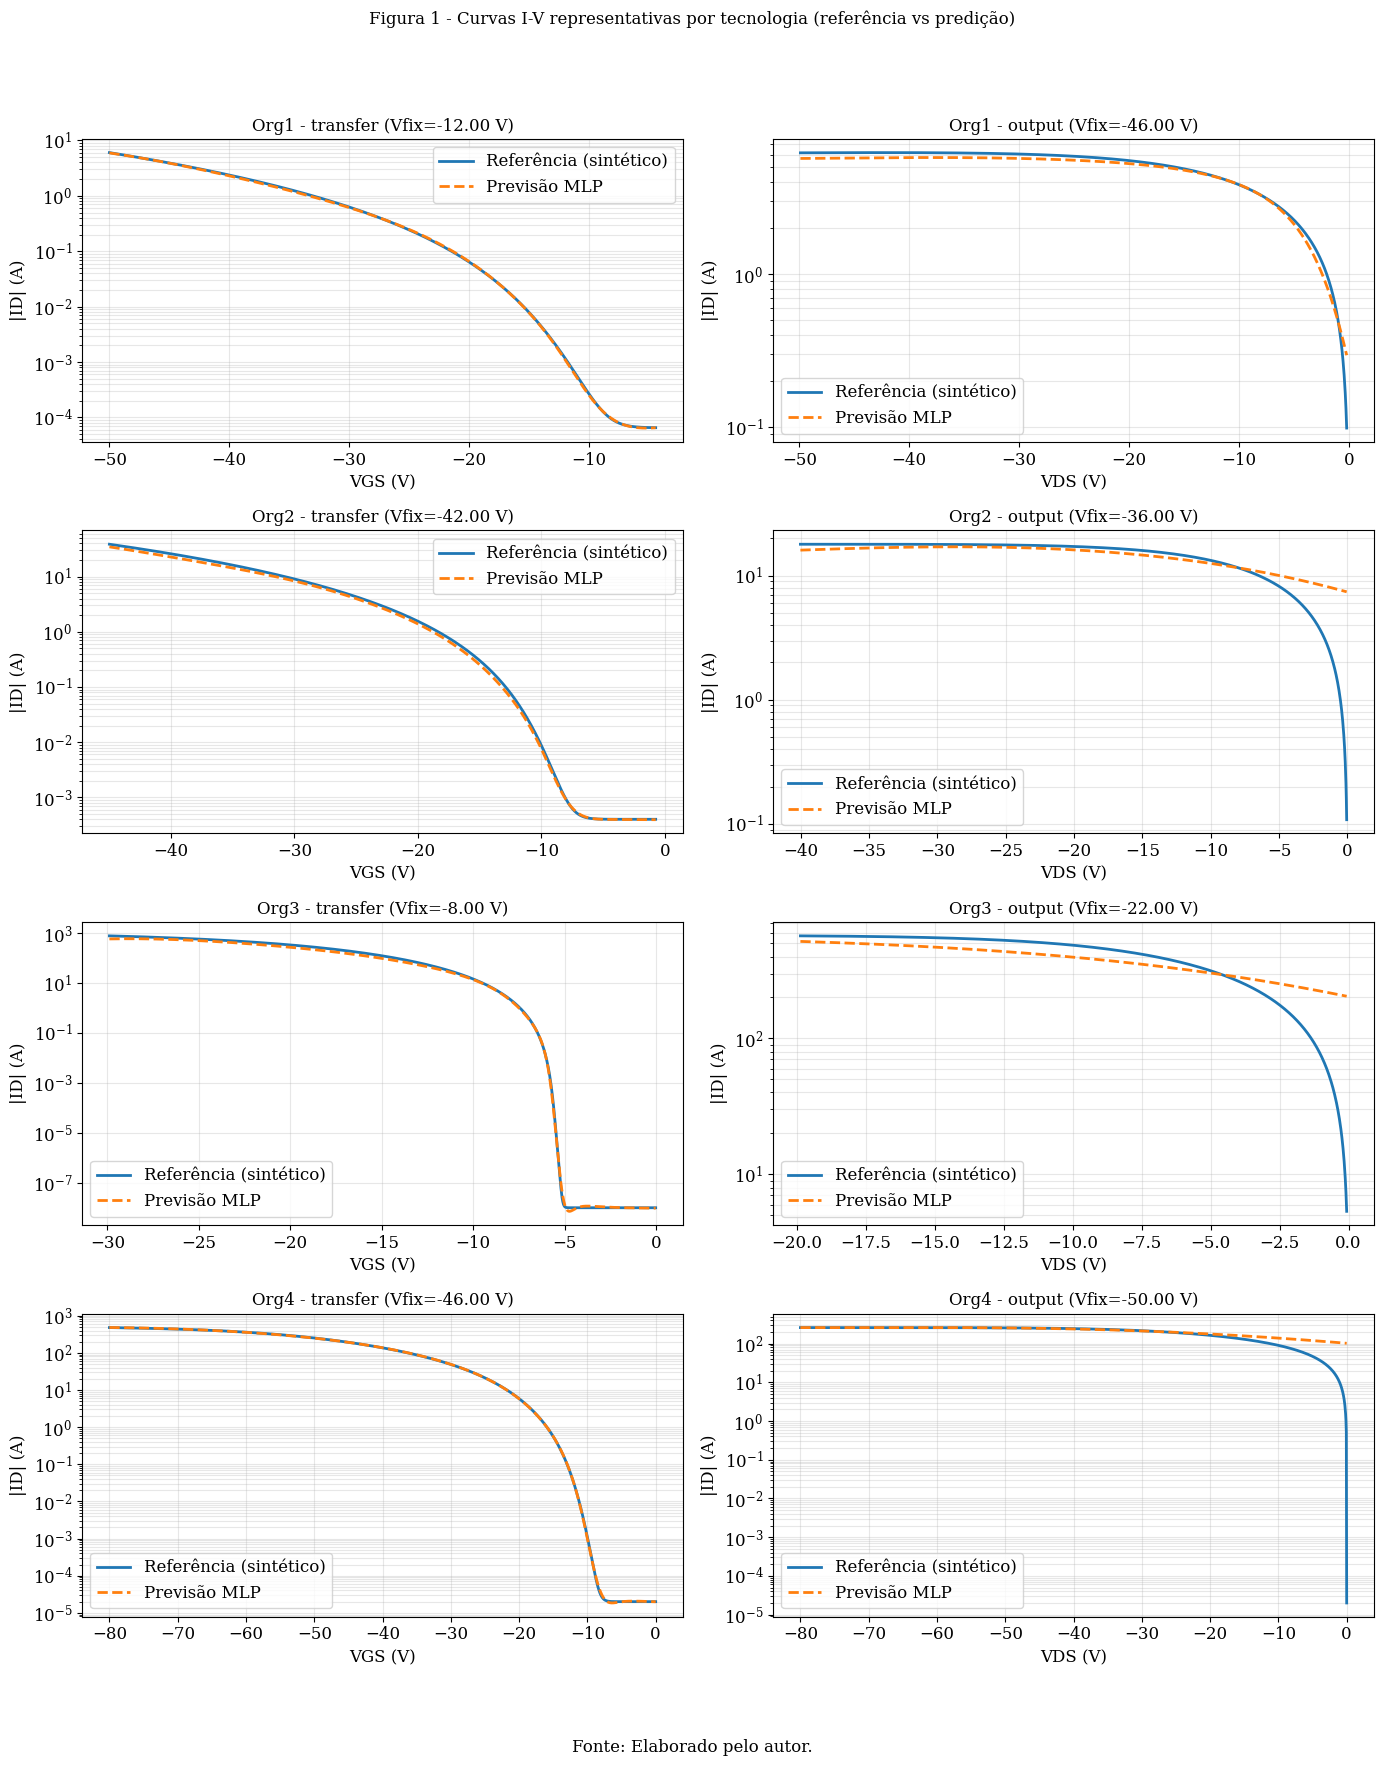

[OK] Figura salva: /home/rsb6/Desktop/TCC/TCC implementation/Model_OTFT/figures_mlp/fig2_paridade_ln.png


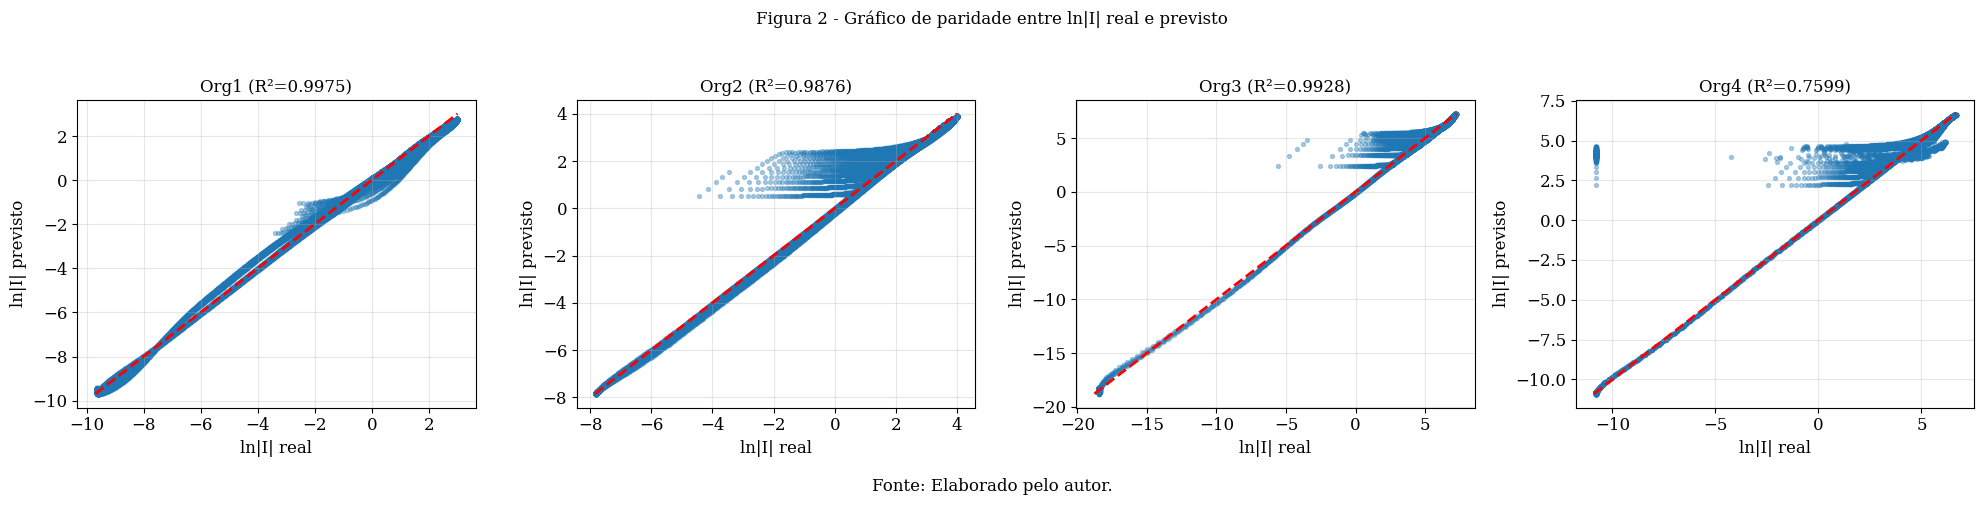

[OK] Figura salva: /home/rsb6/Desktop/TCC/TCC implementation/Model_OTFT/figures_mlp/fig3_comparativo_metricas.png


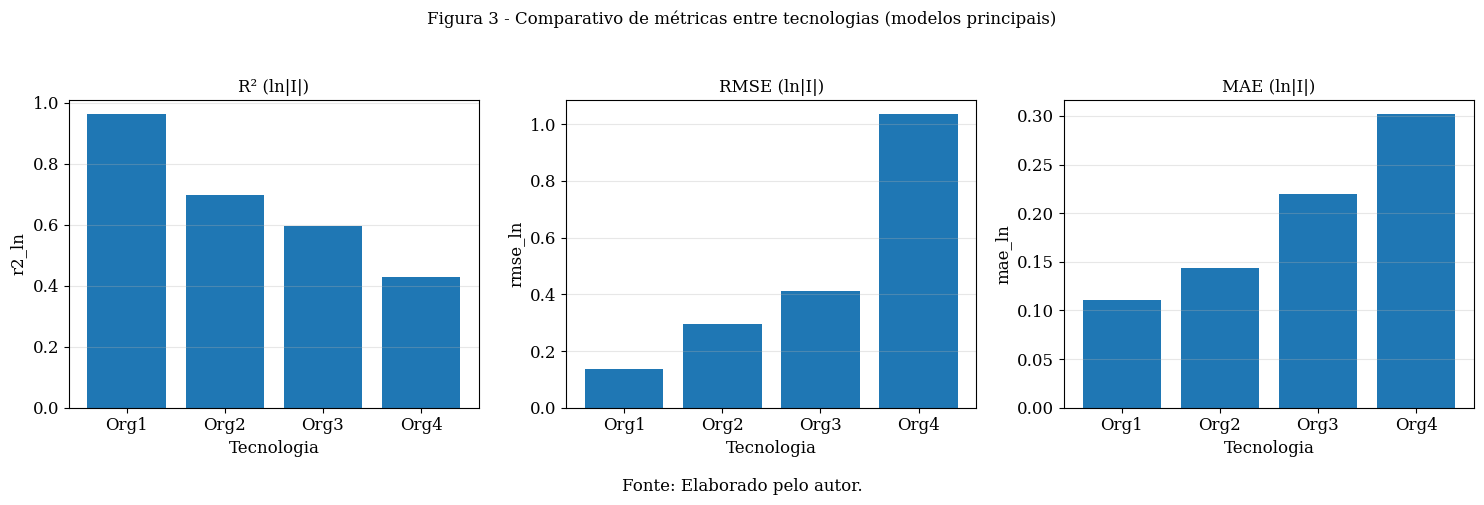

[OK] Figura salva: /home/rsb6/Desktop/TCC/TCC implementation/Model_OTFT/figures_mlp/fig4_residuos_boxplot.png


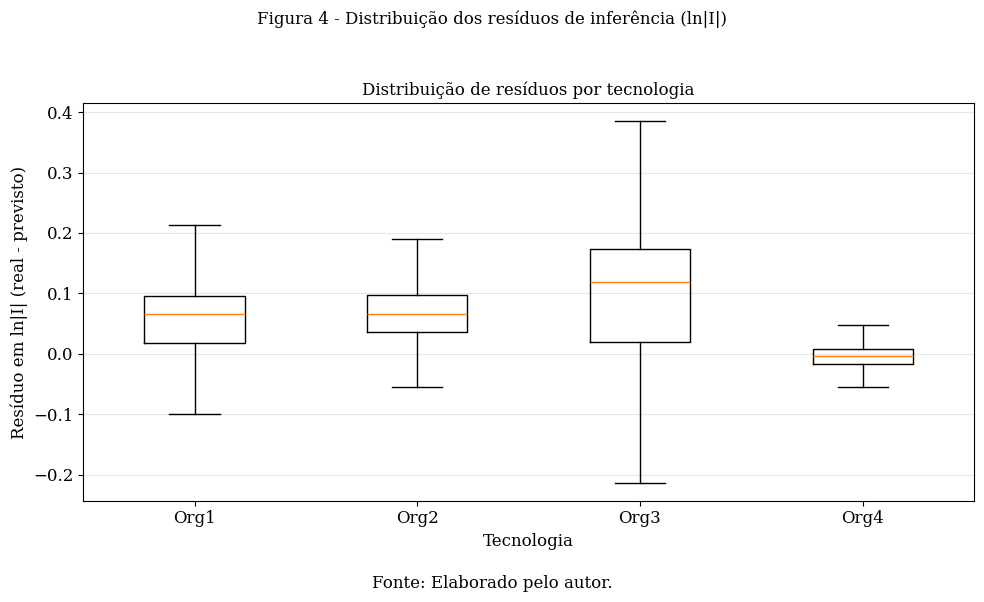

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from typing import Any

# --- Funções Auxiliares (Mantidas conforme seu original) ---

def get_primary_point_rows(org: str) -> list[dict[str, Any]]:
    return [r for r in point_rows if r["org"] == org and r["primary"]]


def choose_representative_curve(rows: list[dict[str, Any]], curve_type: str) -> dict[str, Any] | None:
    candidates = [r for r in rows if r["curve_type"] == curve_type]
    if not candidates:
        return None
    fixed_values = np.array([r["fixed_voltage"] for r in candidates], dtype=float)
    med = np.nanmedian(fixed_values)
    idx = int(np.nanargmin(np.abs(fixed_values - med)))
    return candidates[idx]


# --- Lista de Tecnologias ---
orgs = ["Org1", "Org2", "Org3", "Org4"]
EPS = 1e-12  # Constante assumida para o clipping


# =============================================================================
# Figura 1: Curvas I-V representativas (transfer e output) por tecnologia
# =============================================================================
# CORREÇÃO: nrows alterado para len(orgs) e a altura (figsize) adaptada dinamicamente
fig1, axes1 = plt.subplots(nrows=len(orgs), ncols=2, figsize=(14, 4.5 * len(orgs)), sharex=False, sharey=False)

for row_idx, org in enumerate(orgs):
    rows = get_primary_point_rows(org)
    for col_idx, curve_type in enumerate(["transfer", "output"]):
        ax = axes1[row_idx, col_idx]
        rep = choose_representative_curve(rows, curve_type)

        if rep is None:
            ax.text(0.5, 0.5, f"Sem curva {curve_type}", ha="center", va="center")
            ax.set_title(f"{org} - {curve_type}")
            ax.grid(True, alpha=0.3)
            continue

        x = rep["V"]
        i_true = np.clip(rep["I_true_abs"], EPS, None)
        i_pred = np.clip(rep["I_pred_abs"], EPS, None)

        ax.semilogy(x, i_true, label="Referência (sintético)", linewidth=2)
        ax.semilogy(x, i_pred, "--", label="Previsão MLP", linewidth=2)
        ax.set_xlabel("VGS (V)" if curve_type == "transfer" else "VDS (V)")
        ax.set_ylabel("|ID| (A)")
        ax.set_title(f"{org} - {curve_type} (Vfix={rep['fixed_voltage']:.2f} V)")
        ax.grid(True, which="both", alpha=0.3)
        ax.legend()

salvar_figura_abnt(
    fig1,
    "fig1_curvas_iv_representativas.png",
    "Figura 1 - Curvas I-V representativas por tecnologia (referência vs predição)",
)
plt.show()


# =============================================================================
# Figura 2: Paridade (ln|I| real vs previsto) por tecnologia
# =============================================================================
# CORREÇÃO: ncols alterado para len(orgs) e a largura adaptada dinamicamente
fig2, axes2 = plt.subplots(1, len(orgs), figsize=(5 * len(orgs), 5))

for idx, org in enumerate(orgs):
    ax = axes2[idx]
    rows = get_primary_point_rows(org)

    if not rows:
        ax.text(0.5, 0.5, "Sem dados", ha="center", va="center")
        ax.set_title(org)
        continue

    y_true = np.concatenate([r["y_true_ln"] for r in rows])
    y_pred = np.concatenate([r["y_pred_ln"] for r in rows])

    r2_val = r2_score(y_true, y_pred)

    ax.scatter(y_true, y_pred, s=8, alpha=0.35)
    lim_min = min(float(y_true.min()), float(y_pred.min()))
    lim_max = max(float(y_true.max()), float(y_pred.max()))
    ax.plot([lim_min, lim_max], [lim_min, lim_max], "r--", linewidth=2)

    ax.set_title(f"{org} (R²={r2_val:.4f})")
    ax.set_xlabel("ln|I| real")
    ax.set_ylabel("ln|I| previsto")
    ax.grid(True, alpha=0.3)

salvar_figura_abnt(
    fig2,
    "fig2_paridade_ln.png",
    "Figura 2 - Gráfico de paridade entre ln|I| real e previsto",
)
plt.show()


# =============================================================================
# Figura 3: Barras de métricas comparativas (modelos principais)
# =============================================================================
metric_specs = [
    ("r2_ln", "R² (ln|I|)", False),
    ("rmse_ln", "RMSE (ln|I|)", True),
    ("mae_ln", "MAE (ln|I|)", True),
]

# CORREÇÃO: Subplots ajustados para len(metric_specs) para evitar um quarto eixo vazio
fig3, axes3 = plt.subplots(1, len(metric_specs), figsize=(5 * len(metric_specs), 5))

for ax, (metric_col, title, sort_asc) in zip(axes3, metric_specs):
    chart_df = metrics_primary_df[["org", metric_col]].sort_values("org", ascending=True)
    ax.bar(chart_df["org"], chart_df[metric_col])
    ax.set_title(title)
    ax.set_xlabel("Tecnologia")
    ax.set_ylabel(metric_col)
    ax.grid(axis="y", alpha=0.3)

salvar_figura_abnt(
    fig3,paridade_org1.png
    "fig3_comparativo_metricas.png",
    "Figura 3 - Comparativo de métricas entre tecnologias (modelos principais)",
)
plt.show()


# =============================================================================
# Figura 4: Distribuição de resíduos (ln|I|) por tecnologia
# =============================================================================
# Esta figura já funcionava dinamicamente com base no loop de 'orgs'
fig4, ax4 = plt.subplots(figsize=(10, 6))
residual_data = []
residual_labels = []

for org in orgs:
    rows = get_primary_point_rows(org)
    if rows:
        residuals = np.concatenate([r["residual_ln"] for r in rows])
        residual_data.append(residuals)
        residual_labels.append(org)

if residual_data:
    ax4.boxplot(residual_data, labels=residual_labels, showfliers=False)

ax4.set_title("Distribuição de resíduos por tecnologia")
ax4.set_xlabel("Tecnologia")
ax4.set_ylabel("Resíduo em ln|I| (real - previsto)")
ax4.grid(axis="y", alpha=0.3)

salvar_figura_abnt(
    fig4,
    "fig4_residuos_boxplot.png",
    "Figura 4 - Distribuição dos resíduos de inferência (ln|I|)",
)
plt.show()

## Como usar os resultados no artigo

- Use `figures/metrics_inferencia.csv` como tabela principal de métricas por modelo.
- Use `figures/metrics_inferencia_por_curva.csv` para análises detalhadas por curva.
- As figuras geradas já seguem fonte 12 e rótulos explícitos para inserção no texto.

## Interpretação recomendada

1. **Qualidade global:** priorize `R²`, `RMSE` e `MAE` na escala `ln|I|` (coerente com o alvo de treino).
2. **Desempenho físico:** use métricas na escala absoluta (`*_abs`) para discutir erro em corrente.
3. **Robustez por regime:** compare transfer vs output com a tabela por curva.
4. **Consistência de inferência:** use paridade e resíduos para discutir vieses locais.
